# LAB 2

In [ ]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('/Titanic-Dataset.csv')

# Identifying missing values
print("Missing values using isnull():\n", df.isnull().sum())
print("\nNon-missing values using notnull():\n", df.notnull().sum())

Missing values using isnull():
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Non-missing values using notnull():
 PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64


In [ ]:
# Before cleaning
before_shape = df.shape

# Dropping rows with any missing values
df_cleaned = df.dropna()

# After cleaning
after_shape = df_cleaned.shape

print(f"Size before cleaning: {before_shape}")
print(f"Size after cleaning: {after_shape}")

Size before cleaning: (891, 12)
Size after cleaning: (183, 12)


In [ ]:
# Numerical Imputation (Age)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Categorical Imputation (Embarked)
df['Embarked'] = df['Embarked'].fillna('Unknown')

print("Missing values after imputation:\n", df[['Age', 'Embarked']].isnull().sum())

Missing values after imputation:
 Age         0
Embarked    0
dtype: int64


In [ ]:
print("Data types before:\n", df.dtypes)

# Converting Fare to integer (example)
df['Fare'] = df['Fare'].astype(int)

print("\nData types after conversion:\n", df.dtypes)

Data types before:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Data types after conversion:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare             int64
Cabin           object
Embarked        object
dtype: object


In [ ]:
# Renaming 'Pclass' to 'Passenger_Class'
df_renamed = df.rename(columns={'Pclass': 'Passenger_Class', 'SibSp': 'Siblings_Spouses'})

print(df_renamed.head())

   PassengerId  Survived  Passenger_Class  \
0            1         0                3   
1            2         1                1   
2            3         1                3   
3            4         1                1   
4            5         0                3   

                                                Name     Sex   Age  \
0                            Braund, Mr. Owen Harris    male  22.0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
2                             Heikkinen, Miss. Laina  female  26.0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
4                           Allen, Mr. William Henry    male  35.0   

   Siblings_Spouses  Parch            Ticket  Fare Cabin Embarked  
0                 1      0         A/5 21171     7   NaN        S  
1                 1      0          PC 17599    71   C85        C  
2                 0      0  STON/O2. 3101282     7   NaN        S  
3                 1      0          

In [ ]:
# Example: Replacing inconsistent 'Sex' labels if they existed
df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})

print("Corrected values in 'Sex' column:\n", df['Sex'].unique())

Corrected values in 'Sex' column:
 ['M' 'F']


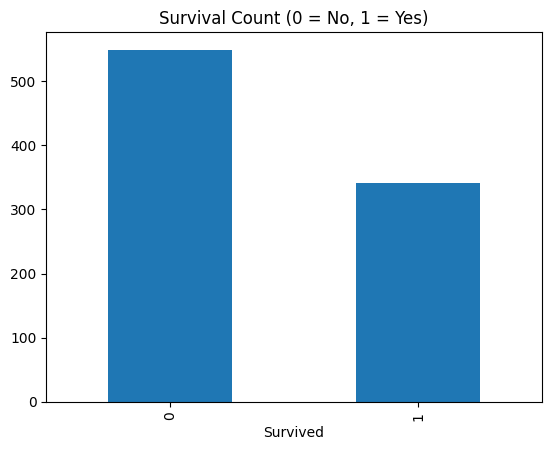

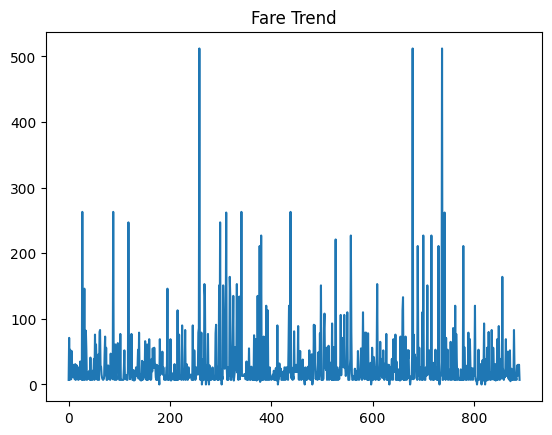

In [ ]:
import matplotlib.pyplot as plt

# Bar Plot (Survival Count)
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()

# Line Plot (Example using PassengerId as a proxy for index/trend)
df['Fare'].plot(kind='line')
plt.title('Fare Trend')
plt.show()

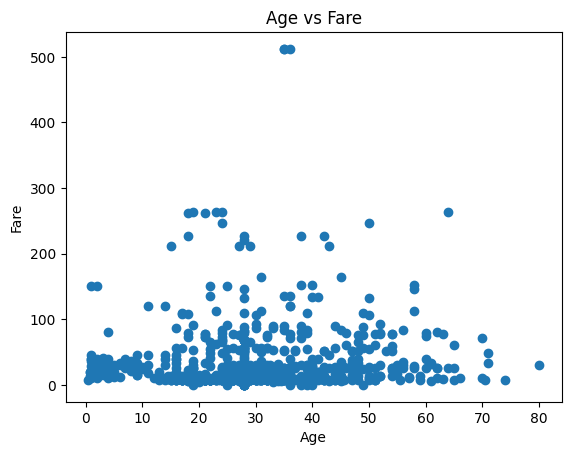

In [ ]:
plt.scatter(df['Age'], df['Fare'])
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare')
plt.show()

# Interpretation: Higher fares don't strictly correlate with age,
# though most high-paying passengers are in the 20-50 age range.

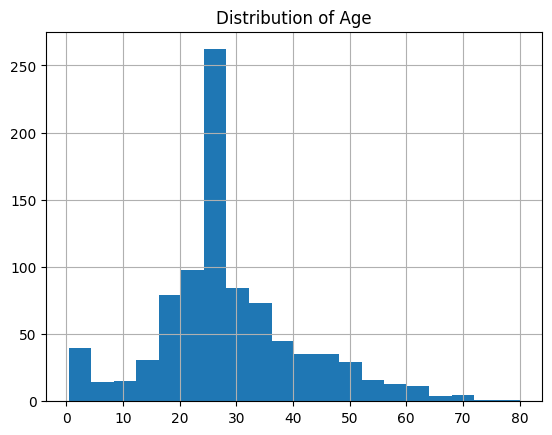

In [ ]:
df['Age'].hist(bins=20)
plt.title('Distribution of Age')
plt.show()

# Interpretation: The distribution is somewhat right-skewed,
# with a peak in the young-adult age group.

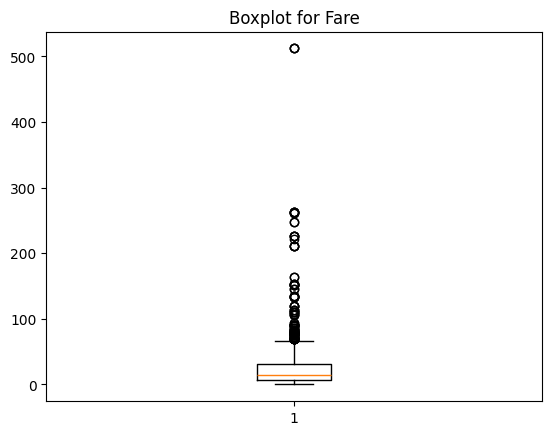

In [ ]:
plt.boxplot(df['Fare'])
plt.title('Boxplot for Fare')
plt.show()

# Interpretation: The points above the top whisker indicate outliers,
# showing passengers who paid significantly higher than the average fare.